# ⚡🇧🇪 What drives electricity prices in **Belgium**?

Belgium is small, gas + nuclear, and one of Europe's **most interconnected** markets — so its
wholesale price is set partly *at home* (gas plants, nuclear, demand) and partly *imported* from
neighbours (cheap French nuclear, German/Dutch gas) across the interconnectors. This notebook
takes those apart.

It is a **hybrid** study:

1. **Structural / counterfactual** — a multi-country `pommes_craft` merit-order model built from
   the **real** fleet (ENTSO-E *ERAA 2024*), **real** fuel + CO₂ prices (ERAA), **real** hourly
   demand (ENTSO-E Power-Statistics) and Ember interconnection. The hourly **clearing price is the
   dual of the energy-balance constraint**. Perturb one factor, re-run, read Belgium's response.
2. **Empirical** — hold the modelled Belgian price against the **real** ENTSO-E day-ahead price
   (activates when a price file is available; see §6).

Everything in the default config is **keyless** (public ERAA archive, public Power-Statistics
load, cached PECD weather) — shareable, no ENTSO-E token needed. Configure it all in
[`config/price_study.yaml`](../config/price_study.yaml).

In [1]:
import sys, os, warnings, logging
warnings.filterwarnings("ignore"); logging.disable(logging.ERROR)
for _p in (os.path.abspath(".."), os.path.abspath(".")):
    if _p not in sys.path: sys.path.insert(0, _p)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.width", 180)
from supplyforge import price_study as ps
print("price_study from:", ps.__file__)

price_study from: /Users/simonbrigode/paper_projects/supplyforge_PECD/supplyforge/price_study.py


## 1 · Configuration

`focus` is the country we zoom in on (**Belgium**). The YAML also pins the coupled country set,
the year, the ERAA/PECD vintages, and the **scenarios** — each overrides a factor relative to
`base`. Belgium-domestic scenarios carry `apply_to: [BE]` so a Belgian shock is separated from a
system-wide one.

In [2]:
cfg = ps.load_config()
cfg.hour_stride = 120   # ~73 representative hours for a snappy demo; YAML default 48; 1 = full year
FOCUS = cfg.focus
print("FOCUS country   :", FOCUS)
print("coupled market  :", cfg.countries)
print("year            :", cfg.year, "| ERAA vintage:", cfg.eraa_target_year, "| weather yr:", cfg.climate_year)
print("hours solved    :", len(cfg.hours))
print("scenarios       :", list(cfg.scenarios))

FOCUS country   : BE
coupled market  : ['BE', 'FR', 'DE', 'NL', 'LU', 'AT', 'CH', 'ES', 'PL']
year            : 2023 | ERAA vintage: 2026 | weather yr: 2008
hours solved    : 73
scenarios       : ['base', 'gas_crisis', 'cheap_gas', 'high_co2', 'no_co2', 'be_nuclear_outage', 'be_nuclear_half', 'be_cold_snap', 'be_offshore_boom', 'be_isolation', 'be_more_interco', 'fr_nuclear_outage', 'de_coal_phaseout', 'cold_snap', 'res_boom']


## 2 · The data behind Belgium (keyless)

One call assembles the **real fleet** (ERAA), **fuel + CO₂ prices** (ERAA), **real hourly demand**
(Power-Statistics, incl. Belgium), **wind/solar capacity factors** (PECD) and **interconnection**
(Ember NTC). Note Belgium's thin domestic dispatchable fleet and its dense border capacity — the
seed of the import story.

In [3]:
data = ps.load_study_data(cfg)
fleet = data.fleet.pivot_table(index="country", columns="category", values="gw", fill_value=0).round(1)
print("Installed capacity by country x technology (GW) — Belgium highlighted:")
fleet.style.apply(lambda r: ["background-color:#fff3bf" if r.name==FOCUS else "" for _ in r], axis=1) \
     if hasattr(fleet, "style") else fleet

Installed capacity by country x technology (GW) — Belgium highlighted:


category,biomass,coal,gas,hydro,lignite,nuclear,oil,other_res,ror,solar,wind_offshore,wind_onshore
country,,,,,,,,,,,,
AT,0.500000,0.000000,3.700000,3.700000,0.000000,0.000000,0.100000,0.000000,4.800000,8.300000,0.000000,5.600000
BE,0.900000,0.000000,5.200000,0.000000,0.000000,2.100000,0.100000,0.000000,0.100000,10.100000,2.300000,3.900000
CH,0.000000,0.000000,0.000000,7.900000,0.000000,2.900000,0.000000,0.400000,4.200000,6.800000,0.000000,0.200000
DE,8.200000,8.100000,26.000000,1.000000,14.100000,0.000000,1.500000,0.000000,3.900000,114.500000,11.800000,66.500000
ES,0.000000,0.000000,25.100000,11.200000,0.000000,7.100000,0.000000,1.400000,3.400000,44.900000,0.000000,36.100000
FR,0.700000,1.700000,7.200000,9.600000,0.000000,63.000000,1.300000,0.700000,13.600000,24.700000,2.000000,24.800000
LU,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000,0.000000,0.300000
NL,1.800000,2.700000,13.300000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,42.800000,6.100000,7.300000
PL,1.600000,13.500000,6.700000,0.200000,6.500000,0.000000,0.000000,0.300000,0.500000,20.400000,1.900000,11.500000


In [4]:
be_links = [(a, b, mw) for a, b, mw in data.links if a == FOCUS or b == FOCUS]
print(f"{FOCUS} demand: mean {data.demand[FOCUS].mean()/1000:.1f} GW, peak {data.demand[FOCUS].max()/1000:.1f} GW")
print(f"{FOCUS} interconnection (Ember NTC, MW):")
for a, b, mw in be_links: print(f"   {a}<->{b}: {mw:.0f}")
print(f"   total border capacity: {sum(mw for *_ , mw in be_links):.0f} MW")
print("\nFuel prices (EUR/MWh_th) + CO2 (EUR/t):", {k: round(v,1) for k,v in data.fuels.items()})

BE demand: mean 9.0 GW, peak 12.6 GW
BE interconnection (Ember NTC, MW):
   BE<->DE: 1000
   BE<->FR: 3800
   BE<->LU: 680
   BE<->NL: 5400
   total border capacity: 10880 MW

Fuel prices (EUR/MWh_th) + CO2 (EUR/t): {'gas': 26.4, 'coal': 10.2, 'lignite': 7.5, 'oil': 54.5, 'nuclear': 7.0, 'biomass': 28.8, 'co2': 73.0}


## 3 · The merit order

The price is set by the most expensive *running* plant. Each firm technology's
SRMC = `fuel/efficiency + CO₂·emission_factor/efficiency + VOM`. Belgium has little cheap
baseload of its own, so when it can't import it falls back onto gas — or, in scarcity, load
shedding.

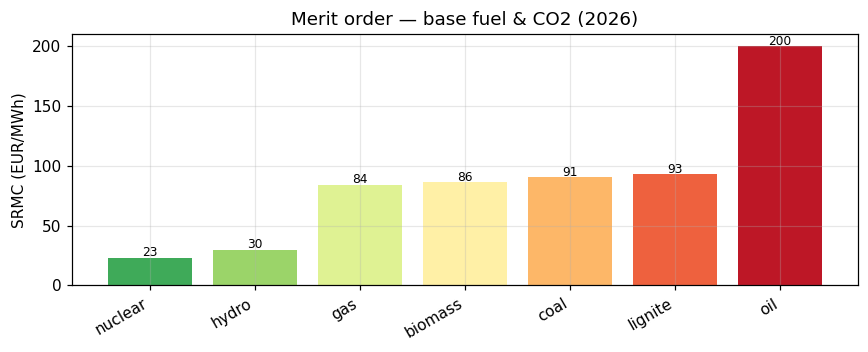

In [5]:
firm = [c for c in ps.FIRM if c != "other_res"]
srmcs = sorted(((c, ps.srmc(c, data.fuels, cfg)) for c in firm), key=lambda x: x[1])
labels, vals = zip(*srmcs)
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.bar(labels, vals, color=plt.cm.RdYlGn_r(np.linspace(.15,.95,len(vals))))
ax.set_ylabel("SRMC (EUR/MWh)"); ax.set_title(f"Merit order — base fuel & CO2 ({cfg.eraa_target_year})")
for i,v in enumerate(vals): ax.text(i, v+1, f"{v:.0f}", ha="center", fontsize=8)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 4 · Base run — where Belgium's price sits

Solve the coupled system and read each country's hourly clearing price.

Writing constraints.:   0%|          | 0/29 [00:00<?, ?it/s]

Writing constraints.:  24%|██▍       | 7/29 [00:00<00:00, 64.47it/s]

Writing constraints.:  83%|████████▎ | 24/29 [00:00<00:00, 118.17it/s]

Writing constraints.: 100%|██████████| 29/29 [00:00<00:00, 120.59it/s]

Writing continuous variables.:   0%|          | 0/17 [00:00<?, ?it/s]

...

Running HiGHS 1.12.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-xs4rnvaf has 58639 rows; 58591 cols; 129253 nonzeros
Coefficient ranges:
  Matrix  [9e-05, 4e+05]
  Cost    [1e-02, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+01, 1e+06]


Presolving model


1314 rows, 8465 cols, 11166 nonzeros  0s
657 rows, 7518 cols, 9562 nonzeros  0s
Dependent equations search running on 657 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
657 rows, 7518 cols, 9562 nonzeros  0s
Presolve reductions: rows 657(-57982); columns 7518(-51073); nonzeros 9562(-119691) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 657(1.124e+07) 1s


       1205     3.1481851957e+10 Pr: 0(0); Du: 0(1.48449e-11) 1s
       1205     3.1481851957e+10 Pr: 0(0); Du: 0(1.48449e-11) 1s

Performed postsolve
Solving the original LP from the solution after postsolve



Model name          : linopy-problem-xs4rnvaf
Model status        : Optimal
Simplex   iterations: 1205
Objective value     :  3.1481851957e+10
P-D objective error :  1.0905417965e-15
HiGHS run time      :          1.13


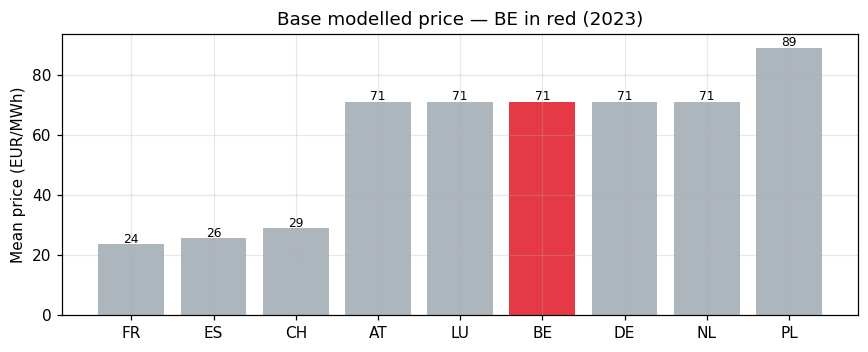

BE mean modelled price: 71.1 EUR/MWh


In [6]:
base = ps.run_scenario(data, "base")
mean_base = base.mean_price().sort_values()
fig, ax = plt.subplots(figsize=(8, 3.3))
colors = ["#e63946" if c == FOCUS else "#adb5bd" for c in mean_base.index]
ax.bar(mean_base.index, mean_base.values, color=colors)
ax.set_ylabel("Mean price (EUR/MWh)"); ax.set_title(f"Base modelled price — {FOCUS} in red ({cfg.year})")
for i,v in enumerate(mean_base.values): ax.text(i, v+0.5, f"{v:.0f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print(f"{FOCUS} mean modelled price: {mean_base[FOCUS]:.1f} EUR/MWh")

## 5 · Is Belgium's price *home-made* or *imported*?

This is the core of the Belgian question. For every hour we ask: **is Belgium importing, and does
its price equal a neighbour's** (price-coupled → the price is set abroad), **or is a Belgian plant
on the margin** (home-made)? `focus_decomposition` labels each hour accordingly.

BE: net importer in 99% of hours, mean net import 3.0 GW
BE: price is IMPORTED (coupled to a cheaper neighbour) 99% of hours, home-made 1%


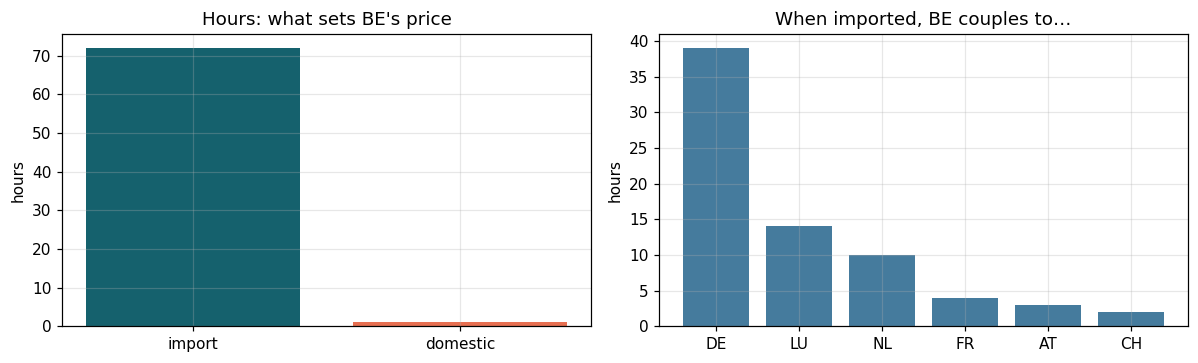

In [7]:
dec = ps.focus_decomposition(base, data, FOCUS)
share_import = (dec.regime == "import").mean()*100
print(f"{FOCUS}: net importer in {(dec.net_import_mw>1).mean()*100:.0f}% of hours, "
      f"mean net import {dec.net_import_mw.mean()/1000:.1f} GW")
print(f"{FOCUS}: price is IMPORTED (coupled to a cheaper neighbour) {share_import:.0f}% of hours, "
      f"home-made {100-share_import:.0f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
# (a) regime split + who Belgium couples to when importing
reg = dec.regime.value_counts()
ax[0].bar(reg.index, reg.values, color=["#15616d","#e76f51"])
ax[0].set_title(f"Hours: what sets {FOCUS}'s price"); ax[0].set_ylabel("hours")
partners = dec[dec.regime=="import"].partner.value_counts()
if len(partners):
    ax[1].bar(partners.index, partners.values, color="#457b9d")
    ax[1].set_title(f"When imported, {FOCUS} couples to…"); ax[1].set_ylabel("hours")
plt.tight_layout(); plt.show()

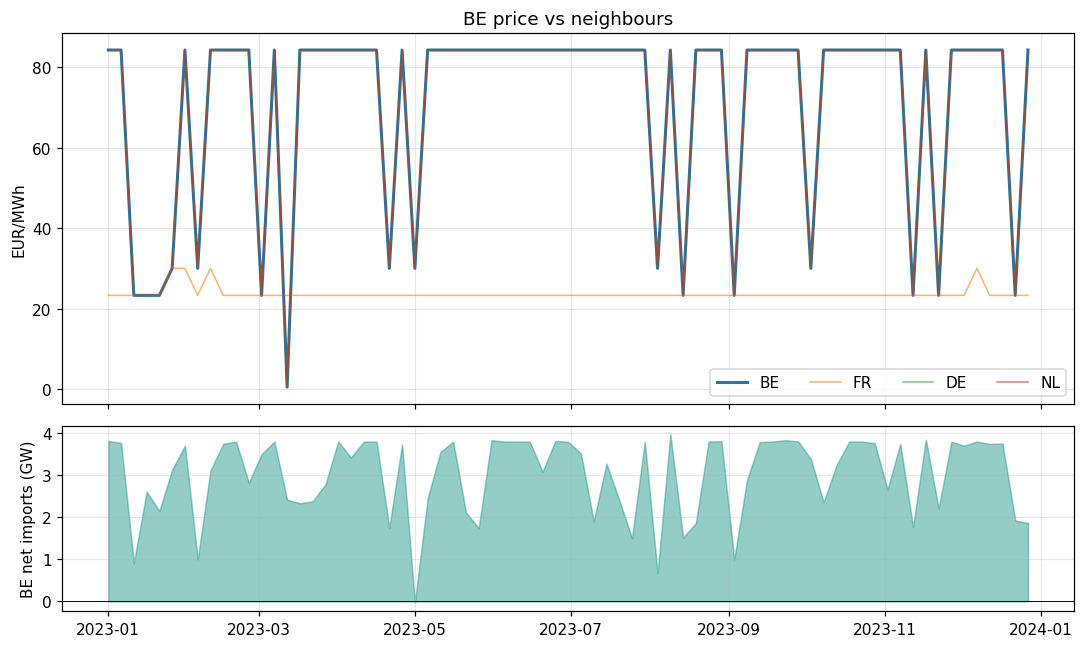

In [8]:
# Belgium's price vs its neighbours' + net imports, over the sampled hours.
ts = ps.price_timestamps(cfg)
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2,1])
for c in [FOCUS, "FR", "DE", "NL"]:
    p = base.prices[base.prices.country==c].sort_values("hour")["price_eur_per_mwh"].to_numpy()
    ax[0].plot(ts, p, label=c, lw=2 if c==FOCUS else 1, alpha=1 if c==FOCUS else .6)
ax[0].set_ylabel("EUR/MWh"); ax[0].legend(ncol=4); ax[0].set_title(f"{FOCUS} price vs neighbours")
ax[1].fill_between(ts, dec.set_index("timestamp")["net_import_mw"]/1000, 0,
                   color="#2a9d8f", alpha=.5)
ax[1].axhline(0, color="k", lw=.6); ax[1].set_ylabel(f"{FOCUS} net imports (GW)")
plt.tight_layout(); plt.show()

## 6 · What moves Belgium's price? — factor attribution

Run every scenario and measure the change in **Belgium's** mean price vs `base`. Scenarios are
grouped: **system-wide** commodity shocks, **Belgium-domestic** shocks (`apply_to: [BE]`),
**interconnection**, and **neighbour** shocks that spill in. This tornado is the headline answer.

Writing constraints.:   0%|          | 0/29 [00:00<?, ?it/s]

Writing constraints.:  24%|██▍       | 7/29 [00:00<00:00, 55.58it/s]

Writing constraints.:  79%|███████▉  | 23/29 [00:00<00:00, 106.92it/s]

Writing constraints.: 100%|██████████| 29/29 [00:00<00:00, 102.63it/s]

Writing continuous variables.:   0%|          | 0/17 [00:00<?, ?it/s]

...

Writing constraints.:  79%|███████▉  | 23/29 [00:00<00:00, 224.81it/s]

Writing constraints.: 100%|██████████| 29/29 [00:00<00:00, 243.74it/s]

Writing continuous variables.:   0%|          | 0/17 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 17/17 [00:00<00:00, 457.38it/s]

Running HiGHS 1.12.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-0gvlw54o has 58639 rows; 58591 cols; 129253 nonzeros
Coefficient ranges:
  Matrix  [9e-05, 4e+05]
  Cost    [1e-02, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [1e+01, 1e+06]
Presolving model
1314 rows, 8465 cols, 11166 nonzeros  0s
657 rows, 7518 cols, 9562 nonzeros  0s
Dependent equations search running on 657 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
657 rows, 7518 cols, 9562 nonzeros  0s
Presolve reductions: rows 657(-57982); columns 7518(-51073); nonzeros 9562(-119691) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 657(1.124e+07) 0s
       1117     1.7531712195e+10 Pr: 0(0); Du: 0(1.33696e-11) 0s
       1117     1.7531712195e+10 Pr: 0(0); Du: 0(1.33696e-11) 0s

Performed postsolve
Solving 

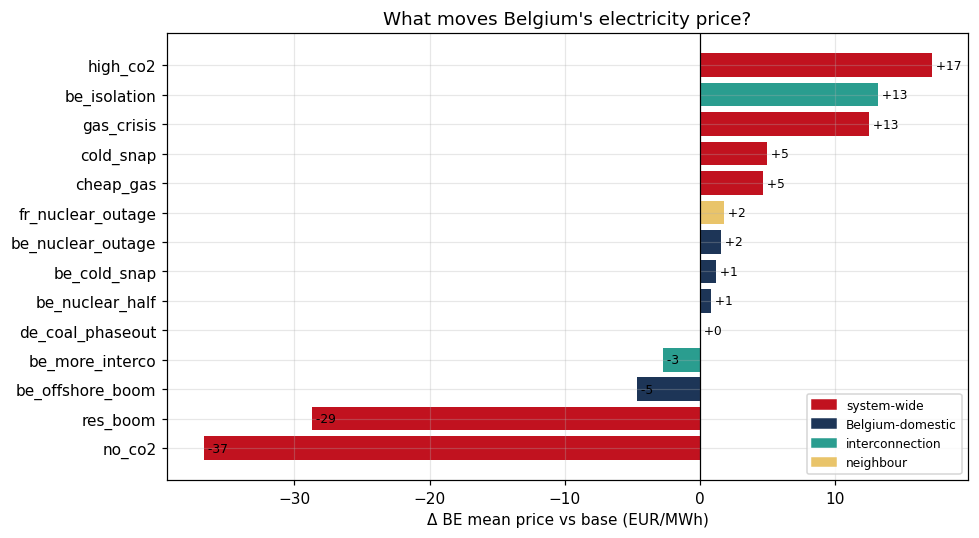

,Δ BE price (EUR/MWh)
no_co2,-36.7
res_boom,-28.7
be_offshore_boom,-4.6
be_more_interco,-2.8
de_coal_phaseout,0.0
be_nuclear_half,0.8
be_cold_snap,1.2
be_nuclear_outage,1.6
fr_nuclear_outage,1.8
cheap_gas,4.6


In [9]:
results = ps.run_all(data)                       # every scenario in the YAML
tbl = ps.attribution_table(results)
be_delta = tbl.loc[FOCUS, [c for c in tbl.columns if c.endswith("_delta")]]
be_delta.index = [c.replace("_delta","") for c in be_delta.index]
be_delta = be_delta.sort_values()

def _kind(name):
    sc = cfg.scenarios.get(name, {})
    at = sc.get("apply_to")
    if "ntc_scale" in sc: return "interconnection"
    if at == [FOCUS]: return "Belgium-domestic"
    if at: return "neighbour"
    return "system-wide"
palette = {"system-wide":"#c1121f","Belgium-domestic":"#1d3557",
           "interconnection":"#2a9d8f","neighbour":"#e9c46a"}
cols = [palette[_kind(n)] for n in be_delta.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(be_delta.index, be_delta.values, color=cols)
ax.axvline(0, color="k", lw=.8); ax.set_xlabel(f"Δ {FOCUS} mean price vs base (EUR/MWh)")
ax.set_title(f"What moves Belgium's electricity price?")
for i,v in enumerate(be_delta.values): ax.text(v, i, f" {v:+.0f}", va="center", fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v,label=k) for k,v in palette.items()], fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()
be_delta.round(1).to_frame(f"Δ {FOCUS} price (EUR/MWh)")

In [10]:
# Full table: every scenario's price for every country (Belgium row first).
levels = tbl[[c for c in tbl.columns if not c.endswith("_delta")]]
ordered = [FOCUS] + [c for c in levels.index if c != FOCUS]
print("Mean modelled price by country x scenario (EUR/MWh):")
levels.loc[ordered]

Mean modelled price by country x scenario (EUR/MWh):


,base,gas_crisis,cheap_gas,high_co2,no_co2,be_nuclear_outage,be_nuclear_half,be_cold_snap,be_offshore_boom,be_isolation,be_more_interco,fr_nuclear_outage,de_coal_phaseout,cold_snap,res_boom
country,,,,,,,,,,,,,,,
BE,71.10,83.63,75.74,88.23,34.38,72.68,71.93,72.25,66.47,84.27,68.35,72.86,71.10,76.08,42.41
AT,71.10,75.50,75.50,87.83,31.04,71.93,71.19,71.19,66.56,71.20,68.35,72.86,71.10,76.11,37.91
CH,29.08,29.08,29.08,29.08,26.99,29.17,29.17,29.17,28.90,29.08,28.99,39.85,29.08,30.75,24.75
DE,71.10,75.50,75.50,87.83,31.04,71.93,71.19,71.19,66.56,71.20,68.35,72.86,71.10,76.11,38.65
ES,25.64,25.64,25.64,25.64,25.64,25.64,25.64,25.64,25.64,25.64,25.82,35.26,25.64,30.21,19.76
FR,23.66,23.66,23.66,23.66,23.57,23.75,23.75,23.75,23.66,23.66,23.85,39.75,23.66,26.07,21.81
LU,71.10,75.50,75.50,87.83,31.04,71.93,71.19,71.19,66.56,71.20,68.35,72.86,71.10,76.11,38.65
NL,71.10,83.63,75.74,88.23,34.37,72.68,71.93,71.93,66.47,71.94,68.35,72.86,71.10,76.08,42.41
PL,89.24,91.04,91.04,144.64,28.15,89.24,89.24,89.24,89.24,89.24,89.24,89.24,2161.52,90.62,78.13


## 7 · Hybrid check — modelled vs **real** Belgian day-ahead prices

The empirical half. It activates when a real ENTSO-E day-ahead parquet exists for the focus
country (cached, copied from a shared bucket, or fetched with an `ENTSOE_API_TOKEN`). Without one,
it explains exactly how to switch it on — the structural study above stands either way.

Modelled vs real day-ahead (EUR/MWh):


,country,modelled_mean,real_mean,bias,mae,corr
0,BE,71.1,84.3,-13.2,32.8,-0.1
1,FR,23.7,85.3,-61.6,64.6,0.4
2,DE,71.1,82.9,-11.8,31.2,-0.1
3,NL,71.1,84.1,-13.0,30.7,-0.1
4,AT,71.1,84.4,-13.3,31.0,-0.0
5,CH,29.1,96.0,-66.9,68.5,-0.2
6,ES,25.6,84.8,-59.2,62.1,0.2
7,PL,89.2,97.6,-8.4,20.8,-0.1


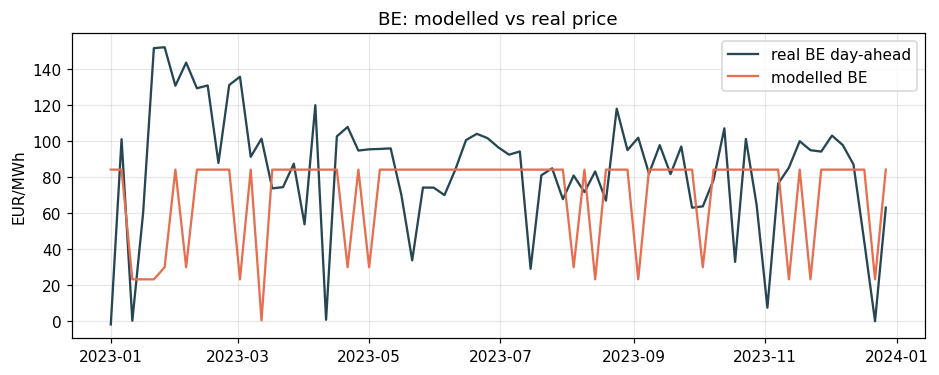

In [11]:
real = ps.real_day_ahead_prices(cfg)
if FOCUS in real:
    cmp = ps.compare_to_real(base, real, cfg)
    print("Modelled vs real day-ahead (EUR/MWh):"); display(cmp)
    rp = ps._to_8760(real[FOCUS].sort_values("timestamp")["price_eur_per_mwh"].to_numpy())[cfg.hours]
    mp = base.prices[base.prices.country==FOCUS].sort_values("hour")["price_eur_per_mwh"].to_numpy()
    fig, ax = plt.subplots(figsize=(10,3.6))
    ax.plot(ts, rp[:len(ts)], label=f"real {FOCUS} day-ahead", lw=1.5, color="#264653")
    ax.plot(ts, mp[:len(ts)], label=f"modelled {FOCUS}", lw=1.5, color="#e76f51")
    ax.set_ylabel("EUR/MWh"); ax.legend(); ax.set_title(f"{FOCUS}: modelled vs real price"); plt.show()
else:
    print(f"No real day-ahead parquet for {FOCUS} @ {cfg.year} — empirical panel inactive.")
    print("To switch it on (real ENTSO-E prices, your key stays local; the notebook stays keyless):\n")
    print(f'  ENTSOE_API_TOKEN=xxxx python -c "from supplyforge.fetch.day_ahead_prices import \\\n'
          f'      fetch_and_save_day_ahead_prices as f; [f(c,{cfg.year}) for c in {cfg.countries}]"\n')
    print("  -> writes results/day_ahead_prices/day_ahead_prices_<CC>_%d.parquet, then re-run." % cfg.year)
    print("  (Or drop those parquet files in from your shared bucket — no key needed to read them.)")

## 8 · Geographic view (optional)

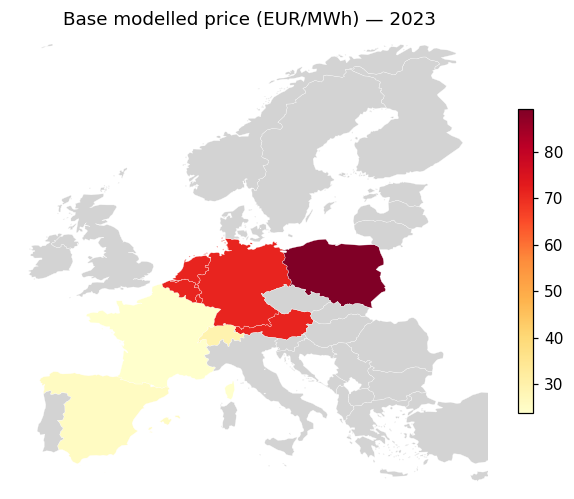

In [12]:
try:
    from supplyforge.fetch.tools.visualisation import maps
    fig, ax = plt.subplots(figsize=(7,6))
    maps.choropleth(mean_base.to_dict(), ax=ax, region="europe", cmap="YlOrRd")
    ax.set_title(f"Base modelled price (EUR/MWh) — {cfg.year}"); plt.show()
except Exception as exc:
    print("Map skipped:", exc)

## 9 · Conclusions — Belgium's price drivers

Read the §6 tornado together with the §5 import split:

- **Belgium is a price-*taker* much of the time.** It is a net importer in most hours, with its
  price coupled to a cheaper neighbour (often France's nuclear or Germany/Netherlands gas). So the
  single biggest lever is **interconnection**: `be_isolation` (cutting Belgium's borders) sends the
  price to scarcity levels, while `be_more_interco` lowers it.
- **System-wide gas and CO₂ prices** pass straight through, because Belgium (and the neighbours it
  imports from) are frequently gas-marginal.
- **Belgian-domestic shocks matter less than you'd think.** A Belgian nuclear outage is largely
  *backfilled by imports*, so its price impact is muted compared with the same nuclear loss in a
  poorly-connected system — a direct, quantified illustration of the value of the grid.
- **Neighbour shocks spill in** (e.g. a French nuclear crunch), confirming Belgium's price is a
  partly-imported quantity.

**Make it yours** — edit [`config/price_study.yaml`](../config/price_study.yaml): change `focus`,
the country set or `year`; add scenarios (`gas_eur_per_gj`, `co2_eur_per_t`, `demand_scale`,
`nuclear_avail`, `coal_avail`, `res_scale`, `ntc_scale`, and `apply_to: [BE]` to target Belgium);
set `hour_stride: 1` for a full-year run.

**Modelling choices & limits** (transparent by design): ERAA 2026 is the closest *real* fleet to a
2023 reanalysis; RES uses a PECD climate year; reservoir hydro is priced at a stylised water value
(no inflow-energy limit); storage / demand-response are out of scope (they would damp peaks);
prices are zonal, not nodal. Each is a clearly-scoped place to deepen.